In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import fastparquet

In [2]:
df_taxi = pd.read_parquet("yellow_tripdata_2026-01.parquet", engine="fastparquet")
df_taxi.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
5,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.2,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
6,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,11.4,4.25,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
7,1,2026-01-01 00:34:28,2026-01-01 00:59:05,0.0,2.90,1.0,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.00,2.5,0.0,0.75
8,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,37.3,1.00,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
9,2,2026-01-01 00:41:07,2026-01-01 00:50:42,3.0,1.83,1.0,N,237,263,1,10.7,1.00,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.00


In [3]:
print(f"df_taxi.shape {df_taxi.shape} \n{'='*50}\nand the df_texi.column is {df_taxi.columns}")

df_taxi.shape (3724889, 20) 
and the df_texi.column is Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')


In [4]:
print(f"shape {df_taxi.shape}\n\n missing value: {df_taxi.isnull().sum()}")

shape (3724889, 20)

 missing value: VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64


In [5]:
df_taxi.nunique()

VendorID                       4
tpep_pickup_datetime     1757191
tpep_dropoff_datetime    1755995
passenger_count               10
trip_distance               4777
RatecodeID                     7
store_and_fwd_flag             2
PULocationID                 262
DOLocationID                 260
payment_type                   5
fare_amount                12867
extra                         45
mta_tax                        6
tip_amount                  4326
tolls_amount                1495
improvement_surcharge          4
total_amount               21228
congestion_surcharge           3
Airport_fee                    8
cbd_congestion_fee             3
dtype: int64

In [6]:
missing_percent = (df_taxi.isnull().sum() / len(df_taxi)) * 100
missing_percent

VendorID                  0.000000
tpep_pickup_datetime      0.000000
tpep_dropoff_datetime     0.000000
passenger_count          29.210481
trip_distance             0.000000
RatecodeID               29.210481
store_and_fwd_flag       29.210481
PULocationID              0.000000
DOLocationID              0.000000
payment_type              0.000000
fare_amount               0.000000
extra                     0.000000
mta_tax                   0.000000
tip_amount                0.000000
tolls_amount              0.000000
improvement_surcharge     0.000000
total_amount              0.000000
congestion_surcharge     29.210481
Airport_fee              29.210481
cbd_congestion_fee        0.000000
dtype: float64

In [7]:
df_taxi.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [8]:
missing_column = []
for m in df_taxi.columns:
    if df_taxi[m].isnull().any():
        missing_column.append(m)

missing_column

['passenger_count',
 'RatecodeID',
 'store_and_fwd_flag',
 'congestion_surcharge',
 'Airport_fee']

In [9]:
for m in missing_column:
    print(df_taxi[m].unique())

[ 1.  0.  4.  2.  3.  5.  6.  9.  7.  8. nan]
[ 1.  4.  2.  5. 99.  3.  6. nan]
['N' 'Y' None]
[ 2.5  0.  -2.5  nan]
[ 0.    1.75  6.75 -1.75 20.    5.   21.75 26.75   nan]


In [10]:
df_taxi_clean = df_taxi.copy()

In [11]:
valid_passenger = df_taxi_clean[
    (df_taxi_clean['passenger_count'] >= 1) &
    (df_taxi_clean['passenger_count'] <= 6)
]['passenger_count']
valid_passenger

0          1.0
3          4.0
5          2.0
6          1.0
8          1.0
          ... 
2636826    1.0
2636827    1.0
2636828    1.0
2636829    4.0
2636830    1.0
Name: passenger_count, Length: 2622037, dtype: float64

In [12]:
passenger_median = valid_passenger.median()
passenger_median

1.0

In [13]:
df_taxi_clean['passenger_count'] = df_taxi_clean['passenger_count'].fillna(passenger_median)
df_taxi_clean['passenger_count'].isnull().sum()

np.int64(0)

<Axes: ylabel='passenger_count'>

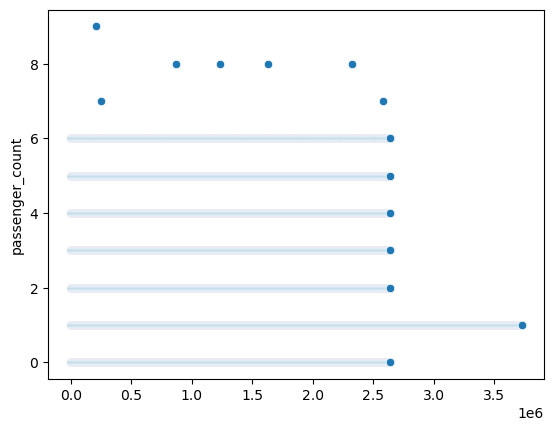

In [14]:
sns.scatterplot(df_taxi_clean['passenger_count'])

In [15]:
df_taxi_clean['RatecodeID'] = df_taxi_clean['RatecodeID'].fillna(99)
df_taxi_clean['RatecodeID'].isnull().sum()

np.int64(0)

In [16]:
df_taxi_clean["RatecodeID"].sample(10)

1726449     1.0
1148975     1.0
2564418     1.0
2757811    99.0
2426256     1.0
2034871     1.0
934448      1.0
3282674    99.0
1370839     1.0
2006040     1.0
Name: RatecodeID, dtype: float64

In [17]:
df_taxi_clean['store_and_fwd_flag'] = df_taxi_clean['store_and_fwd_flag'].fillna('Unknown')
df_taxi_clean["store_and_fwd_flag"].sample(10)

20377            N
1177673          N
921901           N
2152800          N
3395008    Unknown
1716601          N
2807709    Unknown
1036987          N
3279651    Unknown
1686188          N
Name: store_and_fwd_flag, dtype: object

In [18]:
df_taxi_clean['congestion_surcharge'] = df_taxi_clean['congestion_surcharge'].fillna(0)
df_taxi_clean['congestion_surcharge'].sample(10)

2277167    2.5
3518131    0.0
2017471    2.5
357634     2.5
713653     2.5
1681956    0.0
2533195    2.5
1655781    2.5
137137     2.5
1225186    2.5
Name: congestion_surcharge, dtype: float64

In [19]:
df_taxi_clean['Airport_fee'] = df_taxi_clean['Airport_fee'].fillna(0)
df_taxi_clean['Airport_fee'].sample(10)

2061813    0.00
979360     0.00
759598     0.00
1151514    0.00
3225078    0.00
2205351    0.00
2491370    1.75
1864932    0.00
2953556    0.00
1557168    0.00
Name: Airport_fee, dtype: float64

In [20]:
df_taxi_clean['passenger_count'] = df_taxi_clean['passenger_count'].astype(int)
df_taxi_clean['RatecodeID'] = df_taxi_clean['RatecodeID'].astype(int)

In [21]:
df_taxi_clean.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [22]:
df_taxi_clean.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
dtype: int64

In [23]:
numerical_cols = df_taxi.select_dtypes(include=np.number).columns
print(f"numerical_cols are {numerical_cols.__len__()}")
print(numerical_cols)

numerical_cols are 17
Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')


In [24]:
categorical_cols = df_taxi.select_dtypes(include="object").columns
print(f"categorical_cols are {categorical_cols.__len__()}")
print(categorical_cols)

categorical_cols are 1
Index(['store_and_fwd_flag'], dtype='object')


### Variable Classification for Yellow Taxi Dataset

| Column | Type | Subtype | Justification |
|---|---|---|---|
| VendorID | Categorical | Nominal | It is a vendor/provider code. The numbers are labels, not quantities. |
| tpep_pickup_datetime | Numerical/Temporal | Continuous | It represents pickup date and time, which changes continuously. |
| tpep_dropoff_datetime | Numerical/Temporal | Continuous | It represents dropoff date and time, which changes continuously. |
| passenger_count | Numerical | Discrete | It counts the number of passengers, so values are countable. |
| trip_distance | Numerical | Continuous | Distance is measurable and can contain decimal values. |
| RatecodeID | Categorical | Nominal | It represents rate type codes such as standard rate, JFK, Newark, etc. |
| store_and_fwd_flag | Categorical | Nominal | It has categories such as Y, N, or Unknown, with no natural order. |
| PULocationID | Categorical | Nominal | It is a pickup taxi zone code, not a mathematical value. |
| DOLocationID | Categorical | Nominal | It is a dropoff taxi zone code, not a mathematical value. |
| payment_type | Categorical | Nominal | It represents payment method codes such as credit card, cash, no charge, or dispute. |
| fare_amount | Numerical | Continuous | Fare is a measurable money amount and can contain decimals. |
| extra | Numerical | Continuous | Extra charge is a measurable money amount. |
| mta_tax | Numerical | Continuous | MTA tax is a money amount. |
| tip_amount | Numerical | Continuous | Tip is a measurable money amount and can contain decimals. |
| tolls_amount | Numerical | Continuous | Toll amount is a measurable money value. |
| improvement_surcharge | Numerical | Continuous | It is a surcharge amount measured in money. |
| total_amount | Numerical | Continuous | Total fare is a measurable money amount. |
| congestion_surcharge | Numerical | Continuous | It is a congestion charge amount measured in money. |
| Airport_fee | Numerical | Continuous | It is an airport fee amount measured in money. |
| cbd_congestion_fee | Numerical | Continuous | It is a congestion fee amount for Central Business District trips. |

In [25]:
fare_mean = df_taxi_clean['fare_amount'].mean()
fare_std = df_taxi_clean['fare_amount'].std()

print(f"{fare_mean} \n{fare_std}")

20.804253893203267 
18.927007021276765


In [26]:
meaningful_numeric_cols = []
for n in df_taxi_clean.columns:
    if pd.api.types.is_numeric_dtype(df_taxi_clean[n]):
        meaningful_numeric_cols.append(n)

meaningful_numeric_cols

['VendorID',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'cbd_congestion_fee']

In [27]:
range_values = df_taxi_clean[meaningful_numeric_cols].max() - df_taxi_clean[meaningful_numeric_cols].min()
print(range_values.sort_values(ascending=False))

trip_distance            269097.48
total_amount               5120.40
fare_amount                5110.40
tip_amount                  854.88
DOLocationID                264.00
PULocationID                264.00
tolls_amount                216.72
RatecodeID                   98.00
Airport_fee                  28.50
extra                        24.96
passenger_count               9.00
VendorID                      6.00
mta_tax                       5.25
congestion_surcharge          5.00
payment_type                  4.00
improvement_surcharge         2.00
cbd_congestion_fee            1.50
dtype: float64


In [28]:
largest_range_col = range_values.idxmax()
largest_range_value = range_values.max()

largest_range_col, largest_range_value

('trip_distance', 269097.48)

In [29]:
trip_distance_min = df_taxi_clean['trip_distance'].min()
trip_distance_max = df_taxi_clean['trip_distance'].max()

trip_distance_min, trip_distance_max

(0.0, 269097.48)

In [30]:
print(df_taxi_clean['trip_distance'].quantile([0.25, 0.50, 0.75, 0.95, 0.99, 0.999]))

0.250     1.00
0.500     1.81
0.750     3.73
0.950    12.45
0.990    19.54
0.999    29.79
Name: trip_distance, dtype: float64


In [31]:
df_taxi_clean['trip_distance_capped'] = df_taxi_clean['trip_distance'].clip(lower=0, upper=100)
print("Maximum trip_distance after capping:", df_taxi_clean['trip_distance_capped'].max())

Maximum trip_distance after capping: 100.0


In [32]:
trip_distance_mean = df_taxi_clean['trip_distance'].mean()
trip_distance_median = df_taxi_clean['trip_distance'].median()
trip_distance_mode = df_taxi_clean['trip_distance'].mode()[0]

print("Mean trip_distance:", trip_distance_mean)
print("Median trip_distance:", trip_distance_median)
print("Mode trip_distance:", trip_distance_mode)

Mean trip_distance: 6.455646860886331
Median trip_distance: 1.81
Mode trip_distance: 0.0


In [33]:
fare_range = df_taxi_clean['fare_amount'].max() - df_taxi_clean['fare_amount'].min()
fare_variance = df_taxi_clean['fare_amount'].var()
fare_std = df_taxi_clean['fare_amount'].std()

print("Range of fare_amount:", fare_range)
print("Variance of fare_amount:", fare_variance)
print("Standard deviation of fare_amount:", fare_std)

Range of fare_amount: 5110.4
Variance of fare_amount: 358.2315947834599
Standard deviation of fare_amount: 18.927007021276765


In [34]:
q1_tip = df_taxi_clean['tip_amount'].quantile(0.25)
q3_tip = df_taxi_clean['tip_amount'].quantile(0.75)
iqr_tip = q3_tip - q1_tip

print("Q1 of tip_amount:", q1_tip)
print("Q3 of tip_amount:", q3_tip)
print("IQR of tip_amount:", iqr_tip)

Q1 of tip_amount: 0.0
Q3 of tip_amount: 3.71
IQR of tip_amount: 3.71


In [35]:
df_taxi_clean['tpep_pickup_datetime'] = pd.to_datetime(df_taxi_clean['tpep_pickup_datetime'])
df_taxi_clean['tpep_dropoff_datetime'] = pd.to_datetime(df_taxi_clean['tpep_dropoff_datetime'])

df_taxi_clean[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].head()

,tpep_pickup_datetime,tpep_dropoff_datetime
0,2026-01-01 00:54:04,2026-01-01 00:59:37
1,2026-01-01 00:34:04,2026-01-01 00:39:47
2,2026-01-01 00:57:06,2026-01-01 01:05:59
3,2026-01-01 00:15:22,2026-01-01 00:58:10
4,2026-01-01 00:27:13,2026-01-01 00:40:43


In [36]:
df_taxi_clean['trip_duration_min'] = (
    df_taxi_clean['tpep_dropoff_datetime'] - df_taxi_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

df_taxi_clean['pickup_dayofweek'] = df_taxi_clean['tpep_pickup_datetime'].dt.dayofweek
df_taxi_clean['is_weekend'] = (df_taxi_clean['pickup_dayofweek'] >= 5).astype(int)

df_taxi_clean[['trip_duration_min', 'pickup_dayofweek', 'is_weekend']].head()

,trip_duration_min,pickup_dayofweek,is_weekend
0,5.550000,3,0
1,5.716667,3,0
2,8.883333,3,0
3,42.800000,3,0
4,13.500000,3,0


In [37]:
df_taxi_clean['tip_percentage'] = np.where(
    df_taxi_clean['fare_amount'] > 0,
    (df_taxi_clean['tip_amount'] / df_taxi_clean['fare_amount']) * 100,
    np.nan
)
df_taxi_clean['tip_percentage'].head()

0    50.833333
1     0.000000
2    23.364486
3    28.708010
4    28.518519
Name: tip_percentage, dtype: float64

In [38]:
df_taxi_clean['distance_bin'] = pd.cut(
    df_taxi_clean['trip_distance'],
    bins=[0, 1, 3, 5, 10, 100],
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'],
    include_lowest=True
)
df_taxi_clean['distance_bin'].sample(10)

2758901         Short
2182469         Short
2052064    Very Short
1028391         Short
1148747    Very Short
3498868          Long
1968509          Long
3389324         Short
2825998          Long
1665671         Short
Name: distance_bin, dtype: category
Categories (5, object): ['Very Short' < 'Short' < 'Medium' < 'Long' < 'Very Long']

### 1. Is the distribution of trip_distance symmetric or skewed? Justify by comparing mean and median.

In [41]:
trip_mean = df_taxi_clean['trip_distance'].mean()
trip_median = df_taxi_clean['trip_distance'].median()

print(f"mean and median {trip_mean} and {trip_median}")

if trip_mean > trip_median:
    print("The distribution is right-skewed.")
elif trip_mean < trip_median:
    print("The distribution is left-skewed.")
else:
    print("The distribution is approximately symmetric.")

mean and median 6.455646860886331 and 1.81
The distribution is right-skewed.


### 2. Which measure of central tendency is most appropriate for passenger_count? Why?

In [ ]:
print("\n2. Passenger Count Mean:", df_taxi_clean['passenger_count'].mean())
print("Passenger Count Median:", df_taxi_clean['passenger_count'].median())
print("Passenger Count Mode:", df_taxi_clean['passenger_count'].mode()[0])


2. Passenger Count Mean: 1.1814131911044865
Passenger Count Median: 1.0
Passenger Count Mode: 1


Text(0.5, 1.0, 'Passenger Count Distribution')

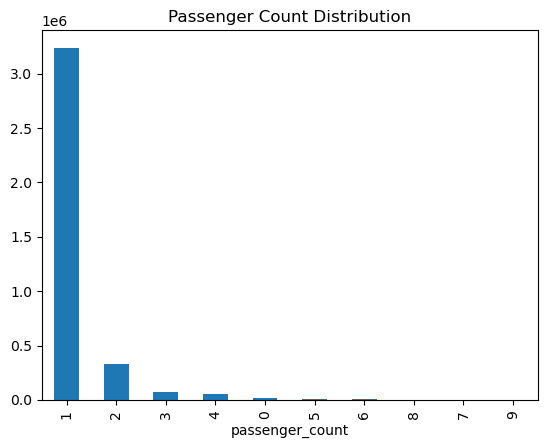

In [42]:
df_taxi_clean['passenger_count'].value_counts().plot(kind='bar')
plt.title('Passenger Count Distribution')

### 3. Why might tip_amount have a large IQR?

In [43]:
tip_q1 = df_taxi_clean['tip_amount'].quantile(0.25)
tip_q3 = df_taxi_clean['tip_amount'].quantile(0.75)
tip_iqr = tip_q3 - tip_q1

print("\n3. Tip Amount Q1:", tip_q1)
print("Tip Amount Q3:", tip_q3)
print("Tip Amount IQR:", tip_iqr)


3. Tip Amount Q1: 0.0
Tip Amount Q3: 3.71
Tip Amount IQR: 3.71


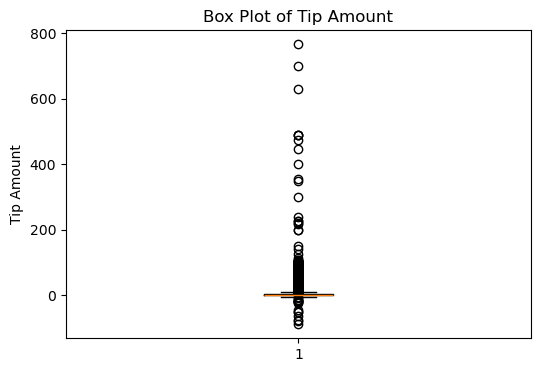

In [44]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_taxi_clean["tip_amount"].dropna())
plt.title("Box Plot of Tip Amount")
plt.ylabel("Tip Amount")
plt.show()

In [42]:
# 4. Percentiles of total_amount
total_percentiles = df_taxi_clean['total_amount'].quantile([0.25, 0.50, 0.75])

print("\n4. 25th, 50th, and 75th percentiles of total_amount:")
print(total_percentiles)


4. 25th, 50th, and 75th percentiles of total_amount:
0.25    17.00
0.50    23.05
0.75    33.83
Name: total_amount, dtype: float64


In [43]:
# 5. Most common payment type and percentage
payment_counts = df_taxi_clean['payment_type'].value_counts()
payment_percent = df_taxi_clean['payment_type'].value_counts(normalize=True) * 100

most_common_payment = payment_counts.idxmax()
most_common_payment_percent = payment_percent.loc[most_common_payment]

print("\n5. Most common payment type:", most_common_payment)
print("Percentage:", most_common_payment_percent)


5. Most common payment type: 1
Percentage: 60.39769238761209


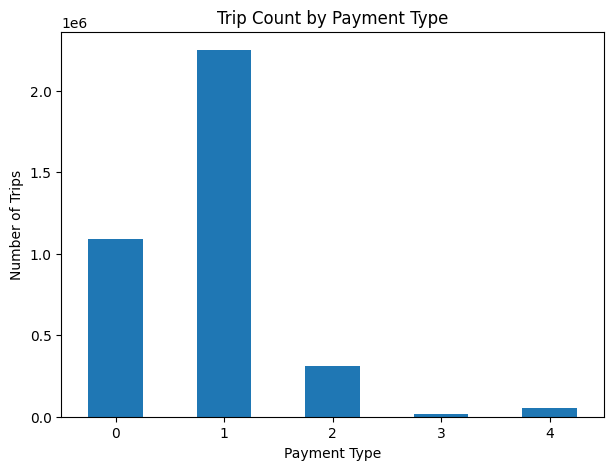

In [44]:
# 6. Bar chart of payment_type
plt.figure(figsize=(7, 5))
df_taxi_clean['payment_type'].value_counts().sort_index().plot(kind='bar')
plt.title('Trip Count by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.show()

In [45]:
# 7. store_and_fwd_flag = Y meaning and percentage
store_flag_percent = (df_taxi_clean['store_and_fwd_flag'].value_counts(normalize=True) * 100)

print("\n7. Store and Forward Flag Percentage:")
print(store_flag_percent)

if 'Y' in store_flag_percent.index:
    print("Percentage of store_and_fwd_flag = Y:", store_flag_percent['Y'])
else:
    print("No Y value found in store_and_fwd_flag.")


7. Store and Forward Flag Percentage:
store_and_fwd_flag
N          70.726779
Unknown    29.210481
Y           0.062740
Name: proportion, dtype: float64
Percentage of store_and_fwd_flag = Y: 0.06274012460505535


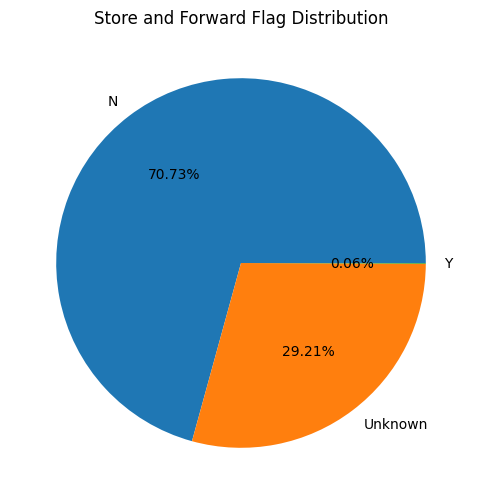

In [46]:
# 8. Pie chart for store_and_fwd_flag
plt.figure(figsize=(6, 6))
df_taxi_clean['store_and_fwd_flag'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%'
)
plt.title('Store and Forward Flag Distribution')
plt.ylabel('')
plt.show()


In [47]:
# 9. Average fare_amount for payment_type 1 vs 2
avg_fare_payment = df_taxi_clean[df_taxi_clean['payment_type'].isin([1, 2])].groupby('payment_type')['fare_amount'].mean()

print("\n9. Average fare_amount for Credit Card vs Cash:")
print(avg_fare_payment)


9. Average fare_amount for Credit Card vs Cash:
payment_type
1    19.558851
2    18.134862
Name: fare_amount, dtype: float64


In [48]:
# 10. Average tip_amount for credit card vs cash
avg_tip_payment = df_taxi_clean[df_taxi_clean['payment_type'].isin([1, 2])].groupby('payment_type')['tip_amount'].mean()

print("\n10. Average tip_amount for Credit Card vs Cash:")
print(avg_tip_payment)


10. Average tip_amount for Credit Card vs Cash:
payment_type
1    4.136821
2    0.000426
Name: tip_amount, dtype: float64


In [49]:
# 11. Average trip_distance for passenger_count = 1
avg_distance_single_passenger = df_taxi_clean[df_taxi_clean['passenger_count'] == 1]['trip_distance'].mean()

print("\n11. Average trip_distance for passenger_count = 1:")
print(avg_distance_single_passenger)


11. Average trip_distance for passenger_count = 1:
6.847683751295138


In [50]:
# 12. Standard deviation of trip_distance for VendorID 1 and 2
std_distance_vendor = df_taxi_clean[df_taxi_clean['VendorID'].isin([1, 2])].groupby('VendorID')['trip_distance'].std()

print("\n12. Standard deviation of trip_distance by VendorID:")
print(std_distance_vendor)



12. Standard deviation of trip_distance by VendorID:
VendorID
1      4.634073
2    727.201742
Name: trip_distance, dtype: float64


In [51]:
# 13. Skewness of fare_amount for trips with tip_amount > 0
fare_skew_tip_positive = df_taxi_clean[df_taxi_clean['tip_amount'] > 0]['fare_amount'].skew()

print("\n13. Skewness of fare_amount for trips with tip_amount > 0:")
print(fare_skew_tip_positive)


13. Skewness of fare_amount for trips with tip_amount > 0:
3.589582955044719


In [52]:
# 14. Mean difference of total_amount between Airport_fee > 0 and Airport_fee = 0
avg_total_airport = df_taxi_clean.groupby(df_taxi_clean['Airport_fee'] > 0)['total_amount'].mean()

airport_paid_mean = avg_total_airport.loc[True]
airport_not_paid_mean = avg_total_airport.loc[False]

mean_difference_airport = airport_paid_mean - airport_not_paid_mean

print("\n14. Average total_amount by Airport Fee status:")
print(avg_total_airport)

print("Mean difference:", mean_difference_airport)


14. Average total_amount by Airport Fee status:
Airport_fee
False    26.173144
True     75.191715
Name: total_amount, dtype: float64
Mean difference: 49.0185711586591


In [53]:
# 15. Average trip_duration_min for weekend vs weekday
avg_duration_weekend = df_taxi_clean.groupby('is_weekend')['trip_duration_min'].mean()

print("\n15. Average trip_duration_min for weekday vs weekend:")
print(avg_duration_weekend)



15. Average trip_duration_min for weekday vs weekend:
is_weekend
0    17.884759
1    15.421457
Name: trip_duration_min, dtype: float64


In [54]:
# 16. Average tip_percentage for credit card payments
avg_tip_percentage_credit = df_taxi_clean[df_taxi_clean['payment_type'] == 1]['tip_percentage'].mean()

print("\n16. Average tip_percentage for credit card payments:")
print(avg_tip_percentage_credit)


16. Average tip_percentage for credit card payments:
25.522722922603382


In [55]:
# 17. Distance bin column already created above
print("\n17. Distance bin column created successfully.")


17. Distance bin column created successfully.


In [56]:
# 18. Count number of trips in each distance_bin
distance_bin_count = df_taxi_clean['distance_bin'].value_counts().sort_index()

print("\n18. Number of trips in each distance_bin:")
print(distance_bin_count)


18. Number of trips in each distance_bin:
distance_bin
Very Short     940249
Short         1633452
Medium         458120
Long           413556
Very Long      279350
Name: count, dtype: int64
